<a href="https://colab.research.google.com/github/HnhanBk415/mliot-pyml-2026-hw/blob/main/week06/Homework_11/buoi11_homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Ensemble Learning Homework — Spaceship Titanic
Họ và tên: Nguyễn Hoàng Nhân
MSSV: 2412415

## Mục tiêu

Notebook này thực hiện đầy đủ quy trình cho bài tập **Ensemble Learning** trên bộ dữ liệu **Spaceship Titanic**:

1. Đọc và khám phá dữ liệu (EDA).
2. Xử lý dữ liệu thiếu và tạo đặc trưng mới (Feature Engineering).
3. Huấn luyện và so sánh nhiều mô hình:
   - Logistic Regression — baseline.
   - Random Forest — Bagging.
   - HistGradientBoosting và CatBoost — Boosting.
   - Stacking — kết hợp nhiều mô hình cơ sở.
4. So sánh benchmark bằng Accuracy.
5. Chọn mô hình/ensemble tốt nhất.
6. Huấn luyện lại trên toàn bộ tập train.
7. Dự đoán tập test và sinh file `submission.csv`.

Kaggle Spaceship Titanic sử dụng **classification accuracy** làm metric đánh giá.

In [1]:
import sys
import subprocess
import warnings
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

try:
    from catboost import CatBoostClassifier
except ImportError:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "catboost"
    ])
    from catboost import CatBoostClassifier

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
import pandas as pd

train_url = "https://raw.githubusercontent.com/AmirFARES/Kaggle-Spaceship-Titanic/main/data/train.csv"
test_url = "https://raw.githubusercontent.com/AmirFARES/Kaggle-Spaceship-Titanic/main/data/test.csv"

train = pd.read_csv(train_url)
test = pd.read_csv(test_url)

print("Train shape:", train.shape)
print("Test shape :", test.shape)

train.head()

Train shape: (8693, 14)
Test shape : (4277, 13)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Kiểm tra cấu trúc dữ liệu

Ta kiểm tra:

- Số lượng dòng/cột.
- Kiểu dữ liệu.
- Các cột bị thiếu.
- Biến mục tiêu `Transported`.

In [3]:
print("TRAIN INFO")
print("=" * 60)
train.info()

print("\nTEST INFO")
print("=" * 60)
test.info()

TRAIN INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   object 
 1   HomePlanet    8492 non-null   object 
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   object 
 4   Destination   8511 non-null   object 
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   object 
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(7)
memory usage: 891.5+ KB

TEST INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4277 entries, 0 to 4276
Data columns (total 13 columns):
 #   Column  

## Kiểm tra dữ liệu thiếu

Dataset có nhiều cột chứa giá trị thiếu.

Thay vì xóa các dòng này, ta sử dụng kỹ thuật **imputation** trong preprocessing pipeline để giữ lại tối đa dữ liệu.

In [4]:
missing = pd.DataFrame({
    "missing_count": train.isna().sum(),
    "missing_percent": train.isna().mean() * 100,
}).sort_values("missing_percent", ascending=False)

missing = missing[missing["missing_count"] > 0]

missing.round(2)

,missing_count,missing_percent
CryoSleep,217,2.50
ShoppingMall,208,2.39
VIP,203,2.34
HomePlanet,201,2.31
Name,200,2.30
Cabin,199,2.29
VRDeck,188,2.16
Spa,183,2.11
FoodCourt,183,2.11
Destination,182,2.09


## Phân bố biến mục tiêu

`Transported = True` nghĩa là hành khách đã được vận chuyển sang chiều không gian khác.

Ta kiểm tra xem hai lớp có cân bằng hay không.

Transported
False    4315
True     4378
Name: count, dtype: int64

Tỉ lệ:
Transported
True     0.5036
False    0.4964
Name: proportion, dtype: float64


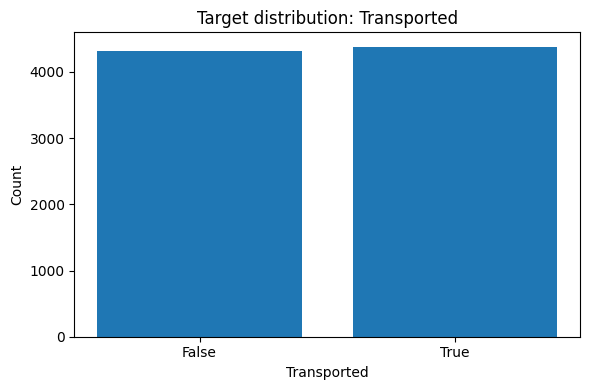

In [5]:
counts = train["Transported"].value_counts().sort_index()

print(counts)

print("\nTỉ lệ:")
print(
    train["Transported"]
    .value_counts(normalize=True)
    .round(4)
)

plt.figure(figsize=(6, 4))

plt.bar(
    counts.index.astype(str),
    counts.values
)

plt.title("Target distribution: Transported")
plt.xlabel("Transported")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## Khám phá các biến categorical quan trọng

Ta kiểm tra tỷ lệ `Transported` theo:

- HomePlanet
- CryoSleep
- Destination
- VIP

Mục tiêu là xác định những feature có khả năng phân biệt hai lớp tốt.

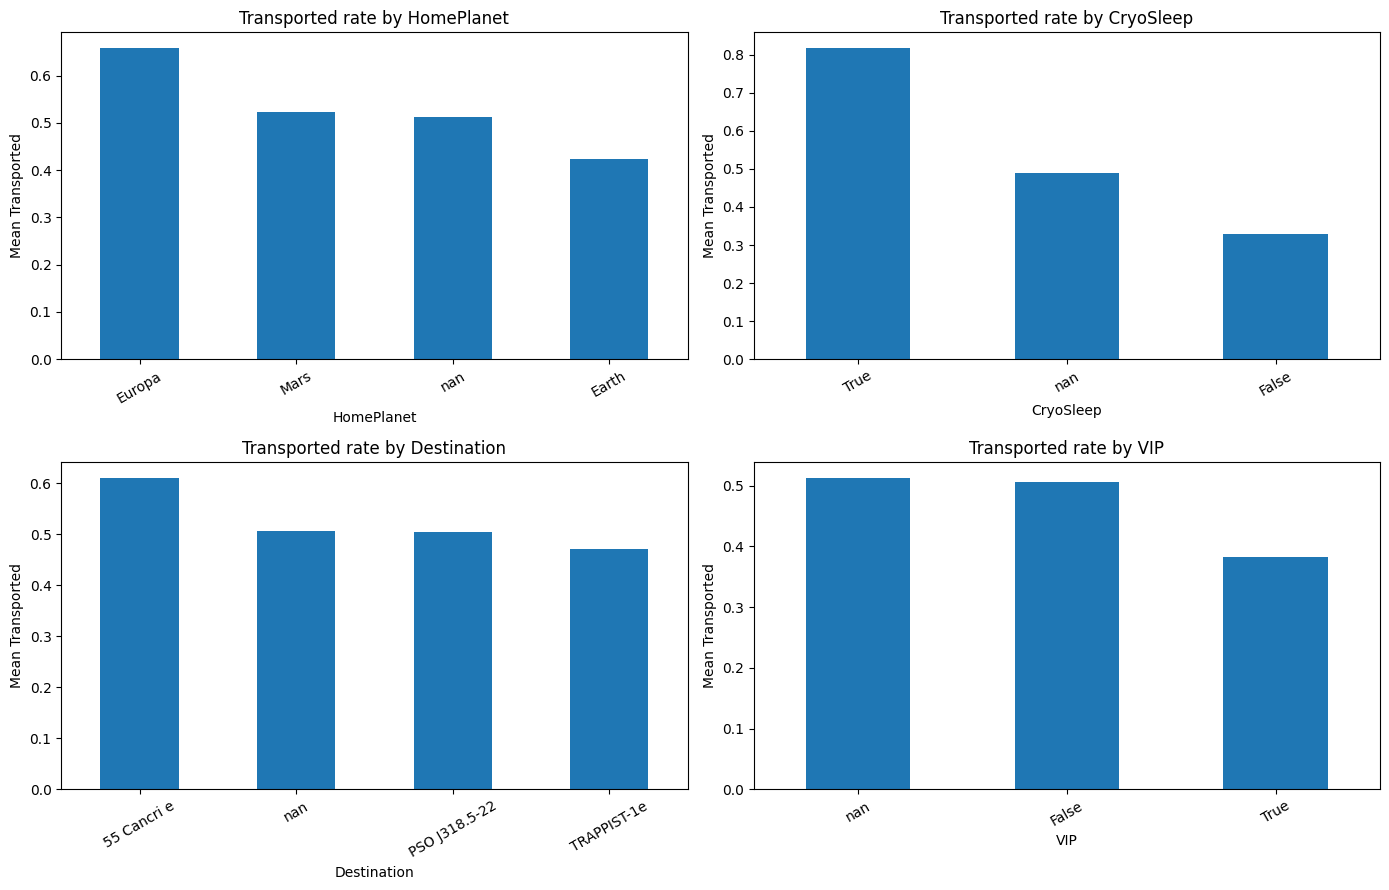

In [6]:
important_cats = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "VIP"
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

axes = axes.ravel()

for ax, col in zip(axes, important_cats):

    rate = (
        train
        .groupby(col, dropna=False)["Transported"]
        .mean()
        .sort_values(ascending=False)
    )

    rate.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Transported rate by {col}")
    ax.set_ylabel("Mean Transported")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

## Khám phá các khoản chi tiêu

Các feature:

- RoomService
- FoodCourt
- ShoppingMall
- Spa
- VRDeck

thể hiện mức sử dụng dịch vụ của hành khách.

Ta tạo thêm `TotalSpend` để quan sát tổng mức chi tiêu của mỗi hành khách.

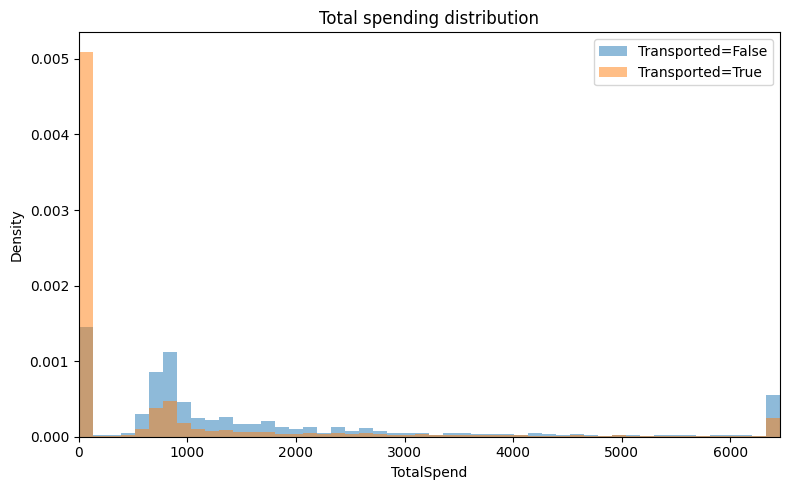

In [7]:
SPEND_COLS = [
    "RoomService",
    "FoodCourt",
    "ShoppingMall",
    "Spa",
    "VRDeck"
]

train_eda = train.copy()

train_eda["TotalSpend"] = (
    train_eda[SPEND_COLS]
    .fillna(0)
    .sum(axis=1)
)

limit = train_eda["TotalSpend"].quantile(0.95)

plt.figure(figsize=(8, 5))

for label in [False, True]:

    values = train_eda.loc[
        train_eda["Transported"] == label,
        "TotalSpend"
    ]

    plt.hist(
        values.clip(upper=limit),
        bins=50,
        alpha=0.5,
        density=True,
        label=f"Transported={label}"
    )

plt.xlim(0, limit)

plt.xlabel("TotalSpend")
plt.ylabel("Density")
plt.title("Total spending distribution")

plt.legend()
plt.tight_layout()
plt.show()

# 🧠 Feature Engineering

Ta tạo thêm các đặc trưng mới từ dữ liệu gốc:

- `GroupId`: nhóm hành khách lấy từ PassengerId.
- `GroupMember`: số thứ tự hành khách trong nhóm.
- `GroupSize`: số người trong nhóm.
- `IsAlone`: hành khách đi một mình.
- `Deck`, `CabinNum`, `Side`: tách từ Cabin.
- `Surname`: họ của hành khách.
- `FamilySize`: số người có cùng họ.
- `TotalSpend`: tổng chi tiêu.
- `HasSpend`: hành khách có chi tiêu hay không.
- `NumServicesUsed`: số dịch vụ đã sử dụng.
- `LuxurySpend`: FoodCourt + ShoppingMall.
- `ServiceSpend`: RoomService + Spa + VRDeck.
- `AgeGroup`: nhóm tuổi.

Feature Engineering giúp mô hình nhận ra các quan hệ mà dữ liệu thô chưa biểu diễn trực tiếp.

In [8]:
def engineer_features(df: pd.DataFrame) -> pd.DataFrame:

    df = df.copy()

    # ==============================
    # Passenger group
    # ==============================

    df["GroupId"] = (
        df["PassengerId"]
        .astype(str)
        .str.split("_")
        .str[0]
    )

    df["GroupMember"] = pd.to_numeric(
        df["PassengerId"]
        .astype(str)
        .str.split("_")
        .str[1],
        errors="coerce",
    )

    df["GroupSize"] = (
        df
        .groupby("GroupId")["PassengerId"]
        .transform("count")
    )

    df["IsAlone"] = (
        df["GroupSize"] == 1
    ).astype(int)

    # ==============================
    # Cabin
    # ==============================

    cabin = (
        df["Cabin"]
        .fillna("Unknown/-1/Unknown")
        .str.split("/", expand=True)
    )

    df["Deck"] = cabin[0]

    df["CabinNum"] = (
        pd.to_numeric(
            cabin[1],
            errors="coerce"
        )
        .replace(-1, np.nan)
    )

    df["Side"] = cabin[2]

    # ==============================
    # Name / Family
    # ==============================

    df["Surname"] = (
        df["Name"]
        .fillna("Unknown")
        .str.split()
        .str[-1]
    )

    df["FamilySize"] = (
        df
        .groupby("Surname")["PassengerId"]
        .transform("count")
    )

    # ==============================
    # Spending
    # ==============================

    spend = df[SPEND_COLS].fillna(0)

    df["TotalSpend"] = spend.sum(axis=1)

    df["HasSpend"] = (
        df["TotalSpend"] > 0
    ).astype(int)

    df["NumServicesUsed"] = (
        spend > 0
    ).sum(axis=1)

    df["LuxurySpend"] = (
        spend["FoodCourt"]
        + spend["ShoppingMall"]
    )

    df["ServiceSpend"] = (
        spend["RoomService"]
        + spend["Spa"]
        + spend["VRDeck"]
    )

    # ==============================
    # Age
    # ==============================

    df["AgeGroup"] = pd.cut(
        df["Age"],
        bins=[
            -np.inf,
            12,
            18,
            25,
            40,
            60,
            np.inf
        ],
        labels=[
            "Child",
            "Teen",
            "YoungAdult",
            "Adult",
            "MiddleAge",
            "Senior"
        ]
    )

    # Raw text columns không cần nữa
    df = df.drop(
        columns=[
            "PassengerId",
            "Cabin",
            "Name"
        ]
    )

    return df


X_all = engineer_features(
    train.drop(columns="Transported")
)

y_all = (
    train["Transported"]
    .astype(int)
)

X_test_all = engineer_features(
    test.copy()
)

print(
    "Engineered train shape:",
    X_all.shape
)

print(
    "Engineered test shape :",
    X_test_all.shape
)

X_all.head()

Engineered train shape: (8693, 25)
Engineered test shape : (4277, 25)


,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,GroupId,GroupMember,GroupSize,IsAlone,Deck,CabinNum,Side,Surname,FamilySize,TotalSpend,HasSpend,NumServicesUsed,LuxurySpend,ServiceSpend,AgeGroup
0,Europa,False,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,0001,1,1,1,B,0.0,P,Ofracculy,1,0.0,0,0,0.0,0.0,Adult
1,Earth,False,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,0002,1,1,1,F,0.0,S,Vines,4,736.0,1,5,34.0,702.0,YoungAdult
2,Europa,False,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,0003,1,2,0,A,0.0,S,Susent,6,10383.0,1,4,3576.0,6807.0,MiddleAge
3,Europa,False,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,0003,2,2,0,A,0.0,S,Susent,6,5176.0,1,4,1654.0,3522.0,Adult
4,Earth,False,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,0004,1,1,1,F,1.0,S,Santantines,6,1091.0,1,5,221.0,870.0,Teen


## Chuẩn bị feature cho từng nhóm mô hình

### Scikit-learn

`GroupId` và `Surname` có số lượng category lớn.

Nếu One-Hot Encoding hai feature này sẽ sinh ra rất nhiều cột, vì vậy ta loại chúng khỏi nhóm model scikit-learn.

### CatBoost

CatBoost có khả năng xử lý categorical feature trực tiếp nên ta giữ `GroupId` và `Surname`.

In [9]:
# =================================
# Feature set cho sklearn
# =================================

HIGH_CARD_COLS = [
    "GroupId",
    "Surname"
]

X_sklearn = X_all.drop(
    columns=HIGH_CARD_COLS
)

X_test_sklearn = X_test_all.drop(
    columns=HIGH_CARD_COLS
)


# =================================
# Feature set cho CatBoost
# =================================

X_cat = X_all.copy()
X_test_cat = X_test_all.copy()

catboost_cat_cols = (
    X_cat
    .select_dtypes(
        include=[
            "object",
            "category",
            "bool"
        ]
    )
    .columns
    .tolist()
)

for col in catboost_cat_cols:

    X_cat[col] = (
        X_cat[col]
        .astype(object)
        .where(
            X_cat[col].notna(),
            "Missing"
        )
        .astype(str)
    )

    X_test_cat[col] = (
        X_test_cat[col]
        .astype(object)
        .where(
            X_test_cat[col].notna(),
            "Missing"
        )
        .astype(str)
    )


print(
    "Sklearn features:",
    X_sklearn.shape[1]
)

print(
    "CatBoost features:",
    X_cat.shape[1]
)

print(
    "CatBoost categorical columns:",
    catboost_cat_cols
)

Sklearn features: 23
CatBoost features: 25
CatBoost categorical columns: ['HomePlanet', 'CryoSleep', 'Destination', 'VIP', 'GroupId', 'Deck', 'Side', 'Surname', 'AgeGroup']


## Chia training và validation

Ta dành:

- 80% dữ liệu để training.
- 20% để validation.

Sử dụng `stratify=y` để giữ tỷ lệ hai lớp Transported gần giống nhau giữa training và validation.

In [10]:
indices = np.arange(
    len(train)
)

train_idx, valid_idx = train_test_split(
    indices,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_all,
)

X_train_sk = (
    X_sklearn
    .iloc[train_idx]
    .copy()
)

X_valid_sk = (
    X_sklearn
    .iloc[valid_idx]
    .copy()
)

X_train_cat = (
    X_cat
    .iloc[train_idx]
    .copy()
)

X_valid_cat = (
    X_cat
    .iloc[valid_idx]
    .copy()
)

y_train = (
    y_all
    .iloc[train_idx]
    .copy()
)

y_valid = (
    y_all
    .iloc[valid_idx]
    .copy()
)

print(
    "Train:",
    X_train_sk.shape,
    y_train.shape
)

print(
    "Valid:",
    X_valid_sk.shape,
    y_valid.shape
)

Train: (6954, 23) (6954,)
Valid: (1739, 23) (1739,)


## Preprocessing

### Numerical features

- Điền missing value bằng median.
- StandardScaler để chuẩn hóa dữ liệu.

### Categorical features

- Điền missing value bằng giá trị xuất hiện nhiều nhất.
- One-Hot Encoding.

Preprocessor chỉ được fit trên training split để tránh data leakage từ validation.

In [11]:
numeric_cols = (
    X_train_sk
    .select_dtypes(
        include=["number"]
    )
    .columns
    .tolist()
)

categorical_cols = (
    X_train_sk
    .select_dtypes(
        exclude=["number"]
    )
    .columns
    .tolist()
)


numeric_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        )
    ),
    (
        "scaler",
        StandardScaler()
    ),
])


categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "onehot",
        OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        )
    ),
])


preprocessor = ColumnTransformer([
    (
        "num",
        numeric_pipeline,
        numeric_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    ),
])


X_train_enc = (
    preprocessor
    .fit_transform(X_train_sk)
)

X_valid_enc = (
    preprocessor
    .transform(X_valid_sk)
)


print(
    "Encoded train shape:",
    X_train_enc.shape
)

print(
    "Encoded valid shape:",
    X_valid_enc.shape
)

Encoded train shape: (6954, 44)
Encoded valid shape: (1739, 44)


# 🤖 Xây dựng các mô hình

Ta so sánh:

### Logistic Regression

Được dùng làm baseline.

### Random Forest

Random Forest thuộc nhóm **Bagging**.

Nhiều Decision Tree được huấn luyện tương đối độc lập trên các tập dữ liệu bootstrap, sau đó kết hợp kết quả dự đoán.

### HistGradientBoosting

Thuộc nhóm **Boosting**.

Các cây được xây dựng tuần tự, trong đó model sau cố gắng sửa lỗi của model trước.

### CatBoost

Cũng thuộc Boosting, đồng thời hỗ trợ xử lý categorical feature hiệu quả.

### Stacking

Ta kết hợp:

- Random Forest
- Extra Trees
- HistGradientBoosting

Sau đó sử dụng Logistic Regression làm meta-model để học cách kết hợp dự đoán của các base learner.

In [12]:
models = {

    "Logistic Regression (Baseline)":
        LogisticRegression(
            max_iter=3000,
            random_state=RANDOM_STATE
        ),

    "Random Forest (Bagging)":
        RandomForestClassifier(
            n_estimators=600,
            max_depth=12,
            min_samples_leaf=2,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),

    "HistGradientBoosting (Boosting)":
        HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=350,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=RANDOM_STATE
        )
}


stacking_model = StackingClassifier(

    estimators=[

        (
            "rf",
            RandomForestClassifier(
                n_estimators=450,
                max_depth=12,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),

        (
            "extra",
            ExtraTreesClassifier(
                n_estimators=450,
                max_depth=14,
                min_samples_leaf=2,
                max_features="sqrt",
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        ),

        (
            "hgb",
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_iter=300,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=RANDOM_STATE
            )
        ),
    ],

    final_estimator=
        LogisticRegression(
            max_iter=2000
        ),

    stack_method="predict_proba",

    cv=5,

    passthrough=False,

    n_jobs=-1
)


models[
    "Stacking (RF + ExtraTrees + HGB)"
] = stacking_model

models.keys()

dict_keys(['Logistic Regression (Baseline)', 'Random Forest (Bagging)', 'HistGradientBoosting (Boosting)', 'Stacking (RF + ExtraTrees + HGB)'])

## Benchmark các mô hình

Để so sánh các kỹ thuật một cách công bằng, ta sử dụng cùng tập validation và cùng metric Accuracy.

Ngoài Accuracy, ta cũng lưu thời gian training để quan sát trade-off giữa hiệu quả và chi phí tính toán.

In [13]:
results = []

fitted_models = {}

validation_probabilities = {}


for name, model in models.items():

    start = perf_counter()

    model.fit(
        X_train_enc,
        y_train
    )

    elapsed = (
        perf_counter()
        - start
    )


    pred = model.predict(
        X_valid_enc
    )

    prob = (
        model
        .predict_proba(X_valid_enc)[:, 1]
    )


    acc = accuracy_score(
        y_valid,
        pred
    )


    fitted_models[name] = model

    validation_probabilities[name] = prob


    results.append({

        "Model": name,

        "Technique": (
            "Baseline"
            if "Baseline" in name

            else "Bagging"
            if "Bagging" in name

            else "Boosting"
            if "Boosting" in name

            else "Stacking"
        ),

        "Validation Accuracy": acc,

        "Train Time (s)": elapsed,
    })


results_df = (
    pd.DataFrame(results)
    .sort_values(
        "Validation Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)

results_df

,Model,Technique,Validation Accuracy,Train Time (s)
0,HistGradientBoosting (Boosting),Boosting,0.821737,4.777061
1,Stacking (RF + ExtraTrees + HGB),Stacking,0.811961,60.213813
2,Random Forest (Bagging),Bagging,0.805060,10.642767
3,Logistic Regression (Baseline),Baseline,0.792984,0.081351


## CatBoost

CatBoost là một Gradient Boosting model hỗ trợ categorical feature trực tiếp.

Ta sử dụng Early Stopping:

Nếu validation performance không cải thiện sau một số iteration, quá trình training sẽ dừng lại để hạn chế overfitting.

In [14]:
cat_model = CatBoostClassifier(

    iterations=1000,

    depth=7,

    learning_rate=0.035,

    loss_function="Logloss",

    eval_metric="Accuracy",

    l2_leaf_reg=5,

    random_strength=0.5,

    random_seed=RANDOM_STATE,

    verbose=False,

    allow_writing_files=False,
)


start = perf_counter()


cat_model.fit(

    X_train_cat,

    y_train,

    cat_features=
        catboost_cat_cols,

    eval_set=(
        X_valid_cat,
        y_valid
    ),

    use_best_model=True,

    early_stopping_rounds=100,

    verbose=False,
)


cat_time = (
    perf_counter()
    - start
)


cat_pred = (
    cat_model
    .predict(X_valid_cat)
    .astype(int)
    .ravel()
)


cat_prob = (
    cat_model
    .predict_proba(X_valid_cat)[:, 1]
)


cat_acc = accuracy_score(
    y_valid,
    cat_pred
)


cat_result = pd.DataFrame([{

    "Model":
        "CatBoost (Boosting)",

    "Technique":
        "Boosting",

    "Validation Accuracy":
        cat_acc,

    "Train Time (s)":
        cat_time
}])


results_df = pd.concat(
    [
        results_df,
        cat_result
    ],
    ignore_index=True
)


results_df = (
    results_df
    .sort_values(
        "Validation Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)


validation_probabilities[
    "CatBoost (Boosting)"
] = cat_prob


results_df

,Model,Technique,Validation Accuracy,Train Time (s)
0,HistGradientBoosting (Boosting),Boosting,0.821737,4.777061
1,Stacking (RF + ExtraTrees + HGB),Stacking,0.811961,60.213813
2,Random Forest (Bagging),Bagging,0.805060,10.642767
3,CatBoost (Boosting),Boosting,0.801035,3.925339
4,Logistic Regression (Baseline),Baseline,0.792984,0.081351


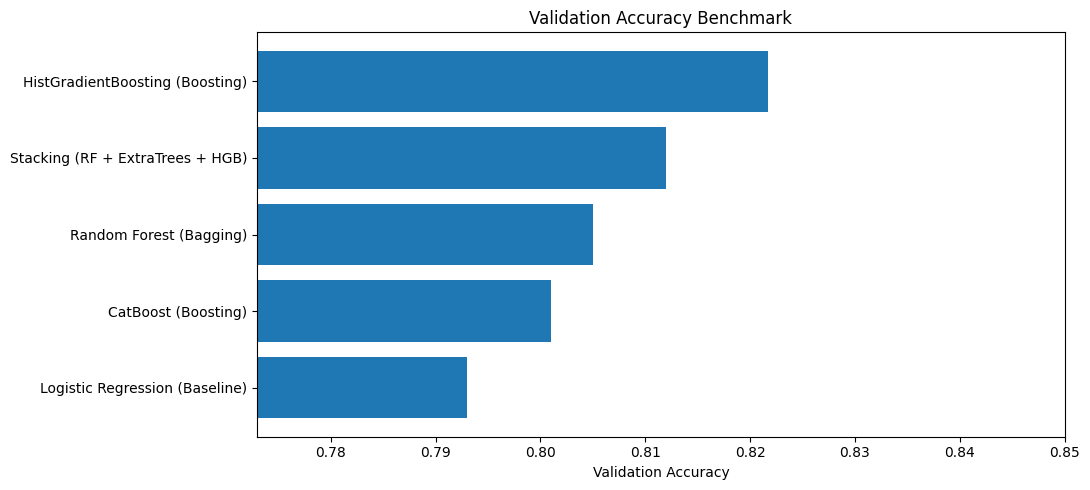

,Model,Technique,Validation Accuracy,Train Time (s)
0,HistGradientBoosting (Boosting),Boosting,0.821737,4.777061
1,Stacking (RF + ExtraTrees + HGB),Stacking,0.811961,60.213813
2,Random Forest (Bagging),Bagging,0.805060,10.642767
3,CatBoost (Boosting),Boosting,0.801035,3.925339
4,Logistic Regression (Baseline),Baseline,0.792984,0.081351


In [15]:
plot_df = (
    results_df
    .sort_values(
        "Validation Accuracy",
        ascending=True
    )
)


plt.figure(
    figsize=(11, 5)
)


plt.barh(
    plot_df["Model"],
    plot_df["Validation Accuracy"]
)


plt.xlim(
    max(
        0.70,
        results_df[
            "Validation Accuracy"
        ].min() - 0.02
    ),
    0.85
)


plt.xlabel(
    "Validation Accuracy"
)

plt.title(
    "Validation Accuracy Benchmark"
)

plt.tight_layout()

plt.show()


results_df

# 🔀 Blending và chọn chiến lược cuối

Ngoài các mô hình riêng lẻ, ta thử **soft blending** giữa:

- CatBoost probability
- Stacking probability

Công thức:

p = w × p(CatBoost) + (1-w) × p(Stacking)

Sau đó ta so sánh bốn chiến lược cuối:

1. HistGradientBoosting
2. CatBoost
3. Stacking
4. CatBoost + Stacking Blend

Chiến lược có Validation Accuracy cao nhất sẽ được dùng để tạo submission.

In [16]:
stack_prob = validation_probabilities[
    "Stacking (RF + ExtraTrees + HGB)"
]

hgb_prob = validation_probabilities[
    "HistGradientBoosting (Boosting)"
]


# =========================================
# 1. Tìm blend tốt CatBoost + Stacking
# =========================================

blend_records = []


for weight_cat in np.arange(
    0.0,
    1.01,
    0.1
):

    blended_prob = (
        weight_cat * cat_prob
        + (1 - weight_cat) * stack_prob
    )


    for threshold in np.arange(
        0.44,
        0.57,
        0.01
    ):

        blended_pred = (
            blended_prob >= threshold
        ).astype(int)


        acc = accuracy_score(
            y_valid,
            blended_pred
        )


        blend_records.append({

            "CatBoost Weight":
                round(
                    float(weight_cat),
                    2
                ),

            "Stacking Weight":
                round(
                    float(1 - weight_cat),
                    2
                ),

            "Threshold":
                round(
                    float(threshold),
                    2
                ),

            "Validation Accuracy":
                acc
        })


blend_df = (
    pd.DataFrame(blend_records)
    .sort_values(
        "Validation Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)


best_blend = blend_df.iloc[0]


best_cat_weight = float(
    best_blend[
        "CatBoost Weight"
    ]
)

best_stack_weight = float(
    best_blend[
        "Stacking Weight"
    ]
)


best_blend_prob = (

    best_cat_weight
    * cat_prob

    +

    best_stack_weight
    * stack_prob
)


# =========================================
# 2. Compare final strategies
# =========================================

candidate_probabilities = {

    "HistGradientBoosting":
        hgb_prob,

    "CatBoost":
        cat_prob,

    "Stacking":
        stack_prob,

    "CatBoost + Stacking Blend":
        best_blend_prob,
}


strategy_records = []


for strategy_name, probability \
        in candidate_probabilities.items():

    for threshold in np.arange(
        0.44,
        0.57,
        0.01
    ):

        pred = (
            probability >= threshold
        ).astype(int)


        acc = accuracy_score(
            y_valid,
            pred
        )


        strategy_records.append({

            "Strategy":
                strategy_name,

            "Threshold":
                round(
                    float(threshold),
                    2
                ),

            "Validation Accuracy":
                acc
        })


strategy_df = (
    pd.DataFrame(strategy_records)
    .sort_values(
        "Validation Accuracy",
        ascending=False
    )
    .reset_index(drop=True)
)


best_strategy_row = (
    strategy_df.iloc[0]
)


best_strategy = (
    best_strategy_row["Strategy"]
)


best_final_threshold = float(
    best_strategy_row["Threshold"]
)


print(
    "Best CatBoost/Stacking blend:"
)

print(best_blend)


print(
    "\nBest final strategy:"
)

print(best_strategy_row)


strategy_df.head(10)

Best CatBoost/Stacking blend:
CatBoost Weight        0.100000
Stacking Weight        0.900000
Threshold              0.470000
Validation Accuracy    0.814836
Name: 0, dtype: float64

Best final strategy:
Strategy               HistGradientBoosting
Threshold                              0.51
Validation Accuracy                0.822312
Name: 0, dtype: object


,Strategy,Threshold,Validation Accuracy
0,HistGradientBoosting,0.51,0.822312
1,HistGradientBoosting,0.50,0.821737
2,HistGradientBoosting,0.52,0.820587
3,HistGradientBoosting,0.49,0.820012
4,HistGradientBoosting,0.48,0.820012
5,HistGradientBoosting,0.47,0.817711
6,HistGradientBoosting,0.46,0.817711
7,HistGradientBoosting,0.53,0.817136
8,HistGradientBoosting,0.44,0.816561
9,HistGradientBoosting,0.45,0.816561


## Đánh giá chiến lược cuối

Ta đánh giá mô hình được chọn bằng:

- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

Không ép buộc phải dùng Stacking nếu một kỹ thuật Ensemble khác đang cho kết quả validation tốt hơn.

Selected strategy: HistGradientBoosting
Selected threshold: 0.51
Final validation accuracy: 0.82231

              precision    recall  f1-score   support

           0     0.8119    0.8355    0.8235       863
           1     0.8331    0.8094    0.8211       876

    accuracy                         0.8223      1739
   macro avg     0.8225    0.8224    0.8223      1739
weighted avg     0.8226    0.8223    0.8223      1739



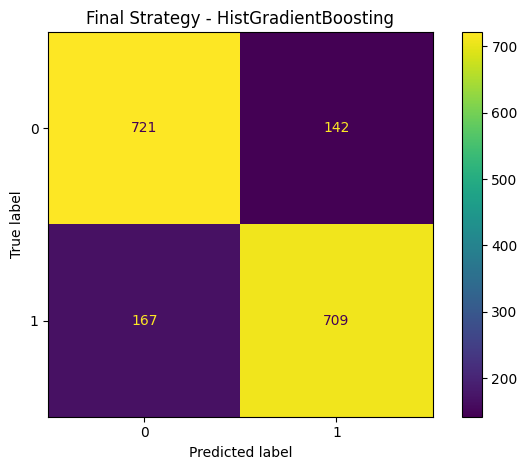

In [17]:
final_valid_prob = (
    candidate_probabilities[
        best_strategy
    ]
)


final_valid_pred = (
    final_valid_prob
    >= best_final_threshold
).astype(int)


final_valid_acc = (
    accuracy_score(
        y_valid,
        final_valid_pred
    )
)


print(
    "Selected strategy:",
    best_strategy
)

print(
    f"Selected threshold: "
    f"{best_final_threshold:.2f}"
)

print(
    f"Final validation accuracy: "
    f"{final_valid_acc:.5f}"
)


print()


print(
    classification_report(
        y_valid,
        final_valid_pred,
        digits=4
    )
)


ConfusionMatrixDisplay.from_predictions(
    y_valid,
    final_valid_pred
)


plt.title(
    f"Final Strategy - "
    f"{best_strategy}"
)

plt.tight_layout()

plt.show()

# 🏁 Huấn luyện trên toàn bộ train

Sau khi chọn chiến lược tốt nhất trên validation, ta huấn luyện lại bằng toàn bộ dữ liệu train.

Quy trình:

1. Fit preprocessing trên toàn bộ train.
2. Fit HistGradientBoosting.
3. Fit Stacking.
4. Fit CatBoost.
5. Dự đoán probability trên test.
6. Nếu chiến lược được chọn là Blend thì kết hợp probability.
7. Dùng threshold đã tìm được để tạo dự đoán cuối.

In [18]:
# =================================
# 1. Full preprocessing
# =================================

full_preprocessor = clone(
    preprocessor
)


X_full_enc = (
    full_preprocessor
    .fit_transform(X_sklearn)
)


X_test_enc = (
    full_preprocessor
    .transform(X_test_sklearn)
)


# =================================
# 2. HistGradientBoosting
# =================================

final_hgb = clone(
    models[
        "HistGradientBoosting (Boosting)"
    ]
)


final_hgb.fit(
    X_full_enc,
    y_all
)


hgb_test_prob = (
    final_hgb
    .predict_proba(X_test_enc)[:, 1]
)


# =================================
# 3. Stacking
# =================================

final_stacking = clone(
    stacking_model
)


final_stacking.fit(
    X_full_enc,
    y_all
)


stack_test_prob = (
    final_stacking
    .predict_proba(X_test_enc)[:, 1]
)


# =================================
# 4. CatBoost
# =================================

best_cat_iterations = (
    cat_model
    .get_best_iteration()
)


if (
    best_cat_iterations is None
    or best_cat_iterations < 0
):

    best_cat_iterations = 700

else:

    best_cat_iterations = max(
        300,
        int(
            best_cat_iterations + 1
        )
    )


final_catboost = CatBoostClassifier(

    iterations=
        best_cat_iterations,

    depth=7,

    learning_rate=0.035,

    loss_function="Logloss",

    eval_metric="Accuracy",

    l2_leaf_reg=5,

    random_strength=0.5,

    random_seed=RANDOM_STATE,

    verbose=False,

    allow_writing_files=False
)


final_catboost.fit(

    X_cat,

    y_all,

    cat_features=
        catboost_cat_cols,

    verbose=False
)


cat_test_prob = (
    final_catboost
    .predict_proba(X_test_cat)[:, 1]
)


# =================================
# 5. Blend
# =================================

blend_test_prob = (

    best_cat_weight
    * cat_test_prob

    +

    best_stack_weight
    * stack_test_prob
)


test_probability_map = {

    "HistGradientBoosting":
        hgb_test_prob,

    "CatBoost":
        cat_test_prob,

    "Stacking":
        stack_test_prob,

    "CatBoost + Stacking Blend":
        blend_test_prob
}


# =================================
# 6. Final prediction
# =================================

final_test_prob = (
    test_probability_map[
        best_strategy
    ]
)


final_test_pred = (

    final_test_prob
    >= best_final_threshold

)


print(
    "Selected strategy:",
    best_strategy
)

print(
    "Selected threshold:",
    best_final_threshold
)

print(
    "CatBoost weight in blend:",
    best_cat_weight
)

print(
    "Stacking weight in blend:",
    best_stack_weight
)

print(
    "Predicted True rate:",
    final_test_pred
    .mean()
    .round(4)
)

Selected strategy: HistGradientBoosting
Selected threshold: 0.51
CatBoost weight in blend: 0.1
Stacking weight in blend: 0.9
Predicted True rate: 0.4982


## Tạo submission.csv

Kaggle yêu cầu file submission gồm hai cột:

- PassengerId
- Transported

Trong đó `Transported` phải chứa giá trị boolean `True/False`.

In [22]:
submission = pd.DataFrame({

    "PassengerId":
        test["PassengerId"],

    "Transported":
        final_test_pred.astype(bool)
})


submission.to_csv(
    "submission.csv",
    index=False
)


print(
    "Saved submission.csv"
)

print(
    "Shape:",
    submission.shape
)


submission.head(10)

Saved submission.csv
Shape: (4277, 2)


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
5,0027_01,False
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True
